# C1 · Week 1 — Content Based Image Retrieval

**Autor:** Martin (Team 4)

**Objetivo de este notebook:** entender bien las decisiones que tengo
que tomar en la Week 1 (histogramas 1D + métrica de similitud) *antes*
de escribir código, y dejar apuntadas **todas** las opciones que la
teoría de la asignatura pone sobre la mesa.

> **Regla del notebook:** toda la información sale de:
> - `Project/C1-W1-2026.pdf` (enunciado de la semana).
> - `Project/C1-project-presentation_2026.pdf` (roadmap del proyecto).
> - `Theory/Semana 01 - 01 - Images and assessment.pdf` (teoría S01).
> - `Theory/Semana 01 - 02 - Lectura complementaria - SSIM.pdf`.
>
> Si algo no aparece en esos PDFs, lo marco explícitamente como
> *"decisión práctica no fijada por la teoría"*.

## 0. Recordatorio del pipeline y de qué tengo que decidir

En W1 la teoría fija la *forma* del sistema pero deja abiertas 5
decisiones. El pipeline (proyecto general, slide 3–4) es siempre:

```
      query                                               ranking top-K
   ┌─────────┐                                          ┌───┬───┬───┐
   │  🖼️     │ ─► descriptor ─► distancia / similitud ─► │ 7 │ 42│ 3 │…
   └─────────┘        ▲                                  └───┴───┴───┘
                      │
                 descriptores
                 de BBDD ya
                 calculados
```

En W1 el descriptor es un **histograma 1D** (slide 7 de `C1-W1-2026`,
literal: *"Compulsory to use 1D histograms!"*).

Las 5 decisiones que tengo que tomar son:

| # | Decisión                                    | Dónde lo dice la teoría |
|---|---------------------------------------------|-------------------------|
| 1 | Espacio de color                            | S01 slide 5; W1 slide 7 |
| 2 | Grayscale vs concatenar canales             | W1 slide 7              |
| 3 | Número de bins del histograma               | (anclada a S01 slide 3) |
| 4 | Normalizar el histograma o no               | (anclada a S01 slide 9) |
| 5 | Métrica de similitud / distancia            | W1 slide 8              |

Como puedo entregar **hasta 2 métodos** (W1 slide 6), al final tengo que
elegir **dos combinaciones** distintas de esas 5 decisiones.

## 1. Decisión — Espacio de color

### Qué dice la teoría

**S01 – Images and assessment, slide 4** define los valores de un píxel:

- **Intensidad luminosa (gris):** valor escalar $I[i, j] \in \mathbb{N}$.
- **Color:** valor vectorial $(R, G, B)$, es decir $I[i, j] \in \mathbb{N}^3$.

**S01, slide 5** lista los espacios de color mencionados en el curso:

- **RGB space** — componentes Red, Green, Blue.
- **Perceptual spaces**: HSV (Hue, Saturation, Value), HSL (Hue,
  Saturation, Luminance), YUV, *etc.*

**W1, slide 7** añade a la lista, específicamente para W1:

- **CieLab**, **YCbCr**, HSV, RGB, *"…"* (la slide deja abierto con
  puntos suspensivos).

### Opciones para W1 (todas salidas del curso)

| Espacio  | ¿En qué PDF sale? | Nota sacada del propio curso |
|----------|-------------------|-------------------------------|
| Gray-level | S01 slide 4       | Valor escalar $I[i,j] \in \mathbb{N}$; único canal. |
| RGB      | S01 slide 5 + W1 slide 7 | Los tres canales primarios de captura. |
| HSV      | S01 slide 5 + W1 slide 7 | Espacio *perceptual* según la teoría. |
| HSL      | S01 slide 5       | Perceptual, mencionado como *e.g.* |
| YUV      | S01 slide 5       | Perceptual, mencionado como *e.g.* |
| YCbCr    | W1 slide 7        | Listado explícito por el enunciado. |
| CieLab   | W1 slide 7        | Listado explícito por el enunciado. |

> La teoría **no dice cuál es mejor** para retrieval; se limita a
> enumerarlos. La comparación empírica es parte del trabajo a hacer.

### 1.b Espacios de color adicionales *(fuera de la teoría del curso)*

> ⚠️ **Los siguientes espacios NO aparecen en las slides de S01 ni en el
> PDF de W1.** Los recojo como opciones que puedo justificar sobre la
> marcha si mejoran mAP@K, siempre citando la fuente en las slides de
> entrega. Si un revisor se ciñe al material del curso, el "core" son
> los de la sección 1.

Todos siguen siendo espacios **de 1 o 3 canales**, así que encajan en
la restricción *"1D histogram"* (uno por canal + concatenación).

#### Perceptuales / device-independent

| Espacio | Canales | Idea rápida | Por qué puede ser útil aquí |
|---|---|---|---|
| **CIE XYZ** | X, Y, Z | Referencia CIE 1931, base de todos los perceptuales. | Baseline device-independent; robusto a variaciones de dispositivo. |
| **CIE L\*u\*v\*** | L*, u*, v* | Hermano perceptual de L\*a\*b\*, uniforme en *croma*. | Alternativa directa a Lab; a veces separa mejor colores muy saturados (típicos en cuadros). |
| **HSI** (Hue, Sat, Intensity) | H, S, I | Variante de HSV/HSL con I = media(R,G,B). | Aísla cromaticidad de luminancia igual que HSV, con `I` más "simétrica". |

#### Invariantes a iluminación

| Espacio | Canales | Idea rápida | Por qué puede ser útil aquí |
|---|---|---|---|
| **Normalized RGB** (`rgb`) | $r = R/(R{+}G{+}B)$, $g = G/(R{+}G{+}B)$, $b = B/(R{+}G{+}B)$ | Divide cada canal por la suma → quita el efecto de intensidad. | Fotos del mismo cuadro a distinta exposición se parecen más. |
| **rg-chromaticity** | $r$, $g$ (2 canales) | Como el anterior pero se descarta $b$ (redundante, $r+g+b=1$). | Descriptor todavía más compacto, sigue siendo 1D histogram por canal. |
| **Log-RGB / log-chromaticity** | $\log R, \log G, \log B$ (o diferencias) | Diferencias de logaritmos anulan factores de iluminación multiplicativos. | Útil frente a variaciones de brillo entre queries y BBDD. |

#### Familias de video / TV (siblings de YUV y YCbCr)

| Espacio | Canales | Idea rápida | Por qué puede ser útil aquí |
|---|---|---|---|
| **YIQ** | Y, I, Q | Old NTSC. Separa luma de dos cromas. | Mismo espíritu que YUV; probar como variante barata. |
| **YPbPr** | Y, Pb, Pr | Video componente analógico. | Sibling de YCbCr sin cuantización estándar; casi equivalente. |
| **YDbDr** | Y, Db, Dr | SECAM. | Otro sibling; útil solo si busco diversificar experimentos. |

#### Decorrelados / basados en oponencia

| Espacio | Canales | Idea rápida | Por qué puede ser útil aquí |
|---|---|---|---|
| **Opponent color** | $O_1 = (R{-}G)/\sqrt{2}$, $O_2 = (R{+}G{-}2B)/\sqrt{6}$, $O_3 = (R{+}G{+}B)/\sqrt{3}$ | Inspirado en la teoría de oponencia del sistema visual. | Decorrelaciona canales antes de histograma; suele reducir redundancia. |
| **Ohta I₁I₂I₃** | $I_1 = (R{+}G{+}B)/3$, $I_2 = R{-}B$, $I_3 = (2G{-}R{-}B)/2$ | Aproximación fija a un PCA de imágenes naturales (Ohta 1980). | Descriptor de canales casi independientes; barato. |
| **HMMD** (Hue, Max, Min, Diff) | H, Max, Min, Diff = Max-Min | Definido por MPEG-7 para *color structure*. | Diseñado específicamente para *content-based retrieval*. |

#### Cuándo pensar en cada uno para W1

- Si observo que fallos de retrieval se explican por **cambios de
  iluminación** → probar `Normalized RGB`, `rg`, `Log-RGB`.
- Si observo que el equipo consigue `mAP@5` similar con RGB y con Lab →
  probar `CIELuv` para ver si separa mejor los colores saturados.
- Si necesito un descriptor **más compacto** sin perder mucha info →
  `rg-chromaticity` (solo 2 canales) o `Ohta I₁I₂I₃` (canales decorrelados).
- Como "gancho" en las slides del equipo, `Opponent` o `HMMD` son fáciles
  de defender: uno tiene motivación biológica, el otro es MPEG-7.

## 2. Decisión — Grayscale vs concatenar histogramas de canales

### Qué dice la teoría

**W1 slide 7** (Task 1) es tajante:

> *"Color Histogram:*
> - *gray level / concatenate color component histograms*
> - *color space RGB, CieLab, YCbCr, HSV, …*
> - ***Compulsory to use 1D histograms!*"**

Y muestra dos ejemplos:

- **level 0**: una única imagen en escala de grises → **un** histograma 1D.
- **level 1**: imagen a color → **tres** histogramas 1D (uno por canal)
  que se **concatenan** en un único vector.

### Opciones para W1

| Opción | Tamaño del descriptor | De dónde sale |
|--------|-----------------------|----------------|
| **Grayscale** — un histograma del canal de gris. | `nbins` | W1 slide 7 (*"gray level"*) |
| **Concat 3 canales** — histograma de cada canal del espacio elegido, concatenados. | `3 · nbins` | W1 slide 7 (*"concatenate color component histograms"*) |

> **Prohibido en W1:** histogramas 2D o 3D (*"Compulsory to use 1D"*).
> Se reservan para W2 (histogramas por bloques) según el roadmap del
> proyecto (`C1-project-presentation`, slide 4).

## 3. Decisión — Número de bins del histograma

### Qué es un bin (anclado a la teoría)

**S01 – Images and assessment, slide 3** dice literalmente:

> *"Digital images are multidimensional matrices formed by a process of
> **sampling and quantization** of a continuous and analog function."*

Es decir: los valores de intensidad ya vienen **cuantizados** (típicamente
$I[i,j] \in \mathbb{N}$, 8 bits → 256 niveles posibles).

Un **histograma con `nbins` bins** vuelve a cuantizar ese eje de
intensidad, agrupando los 256 niveles originales en `nbins` "cubos":

- Si `nbins = 256` → un bin por nivel de intensidad (máximo detalle).
- Si `nbins = 64`  → cada bin agrupa 4 niveles consecutivos (256 / 64).
- Si `nbins = 16`  → cada bin agrupa 16 niveles consecutivos.

### El compromiso

La teoría no fija el valor, pero el mecanismo se entiende directamente
desde la idea de *quantization* de la slide 3:

- **Muchos bins** (256, 128) → descriptor más **detallado**, más
  sensible a diferencias finas de color, pero también más sensible al
  ruido y a pequeños cambios de iluminación.
- **Pocos bins** (16, 8) → descriptor más **robusto** y compacto, pero
  puede confundir cuadros que solo se diferencian en matices sutiles.

### Opciones prácticas que voy a barrer

> *Decisión práctica no fijada por la teoría:* usaré potencias de 2
> por comodidad de manejo.

- `nbins ∈ { 8, 16, 32, 64, 128, 256 }`

Tamaño del descriptor final = `nbins` (grayscale) o `3 · nbins`
(concat 3 canales). Ejemplo: HSV con `nbins = 64` y concat → vector de
$3 \times 64 = 192$ valores por imagen.

## 4. Decisión — Normalizar el histograma

### Por qué me lo planteo (anclado a la teoría)

**S01 slide 9** define las métricas de fidelidad MSE y MAD **ya
normalizadas** por el tamaño de la imagen:

$$
\sigma_{\text{MSE}}^{2} \;\equiv\; \frac{1}{NM} \sum_{i=1}^{N}\sum_{j=1}^{M} \bigl|e[i,j]\bigr|^{2}
\qquad
C_{\text{MAD}} \;\equiv\; \frac{1}{NM} \sum_{i=1}^{N}\sum_{j=1}^{M} \bigl|e[i,j]\bigr|
$$

Ese factor $\tfrac{1}{NM}$ no está por casualidad: sirve para que la
medida sea **comparable entre imágenes de tamaño distinto**. La misma
idea se aplica al histograma.

### Qué pasa si NO normalizo

Un histograma "sin normalizar" simplemente **cuenta píxeles** por bin.
Dos cuadros del mismo motivo pero fotografiados a distinta resolución
tendrán histogramas con alturas muy diferentes:

```
   Imagen A: 200 × 200 = 40 000 píxeles
   histograma sin normalizar (cuentas absolutas)
        █
        █           altura máx ~ 2 000
        █ ▄
        █ █ ▄ ▁
      ──┴─┴─┴─┴──  bin


   Imagen B: 500 × 500 = 250 000 píxeles (mismo motivo)
   histograma sin normalizar
        █
        █
        █          altura máx ~ 12 500
        █          (6.25 × más alto porque tiene 6.25 × más píxeles)
        █ ▄
      ──┴─┴─┴─┴──  bin
```

Aunque los dos histogramas tienen la **misma forma**, cualquier distancia
que sume diferencias bin-a-bin (L1, L2, χ² — ver decisión 5) va a decir
que están **muy lejos** solo por la diferencia de tamaño. Mal.

### Qué pasa si SÍ normalizo

Se divide cada bin por el **número total de píxeles** de la imagen
($N \cdot M$). Entonces:

- Todos los histogramas **suman 1** (son distribuciones de probabilidad).
- La forma se conserva, el efecto del tamaño desaparece.

```
   Después de dividir por el nº total de píxeles:

   A:  ▂█▅▂▁▁            B:  ▂█▅▂▁▁
       └── suma 1 ──┘        └── suma 1 ──┘

   → ahora sí son comparables bin a bin.
```

### Opciones para W1

| Opción           | Descripción | Cuándo tiene sentido |
|------------------|-------------|----------------------|
| **Sin normalizar** | $h(i)$ = número de píxeles del bin $i$. | Solo si comparo imágenes ya del mismo tamaño (no es nuestro caso: la BBDD y las queries pueden variar). |
| **Normalizado $L_1$** | $h(i) \leftarrow h(i) / \sum_i h(i)$, suma 1. | Es la análoga del $\tfrac{1}{NM}$ de MSE/MAD. **Es la opción por defecto.** |

> *Nota:* la teoría W1 no lo dice explícitamente palabra a palabra, pero
> el criterio $\tfrac{1}{NM}$ de la slide 9 es exactamente el mismo
> principio: hacer la medida invariante al tamaño.

## 5. Decisión — Métrica de similitud / distancia

### Qué dice la teoría

**W1, slide 8** lista **exactamente estas cinco** medidas y sus fórmulas.
Sean $h_1, h_2$ dos histogramas de $N$ bins.

#### Distancias (a menor valor, más parecidos)

**Euclidean distance ($L_2$)**

$$
D(h_1, h_2) \;=\; \sqrt{\sum_{i=1}^{N} \bigl(h_1(i) - h_2(i)\bigr)^{2}}
$$

**$L_1$ distance**

$$
D(h_1, h_2) \;=\; \sum_{i=1}^{N} \bigl|\, h_1(i) - h_2(i) \,\bigr|
$$

**Chi-square distance ($\chi^{2}$)**

$$
D(h_1, h_2) \;=\; \sum_{i=1}^{N} \frac{\bigl(h_1(i) - h_2(i)\bigr)^{2}}{h_1(i) + h_2(i)}
$$

#### Similitudes (a mayor valor, más parecidos)

**Histogram intersection**

$$
I(h_1, h_2) \;=\; \sum_{i} \min\!\bigl(h_1(i), h_2(i)\bigr)
$$

**Hellinger kernel**

$$
K(h_1, h_2) \;=\; \sum_{i=1}^{N} \sqrt{\, h_1(i) \cdot h_2(i) \,}
$$

### Conexión con la teoría S01

La slide 9 del PDF de assessment ya usaba las mismas dos "familias":

- **MAD** $= \tfrac{1}{NM}\sum|e[i,j]|$ → misma forma que $L_1$
  (norma de la diferencia).
- **MSE** $= \tfrac{1}{NM}\sum|e[i,j]|^{2}$ → misma forma que $L_2^{2}$
  (norma cuadrática de la diferencia).

Es decir, $L_1$ y $L_2$ **no son nuevas**: son las mismas normas de
fidelidad, pero aplicadas a los descriptores (histogramas) en lugar de
a los píxeles.

Las otras tres ($\chi^{2}$, intersección, Hellinger) son específicas de
histogramas y las introduce W1 slide 8 sin más contexto teórico.

### Ojo con distancia vs similitud

Es la fuente típica de bugs al construir el ranking:

| Tipo         | Cómo se ordena para el top-K |
|--------------|-------------------------------|
| **Distancia** ($L_1, L_2, \chi^{2}$) | **ascendente** (pequeño = parecido) |
| **Similitud** ($I, K$)               | **descendente** (grande = parecido) |

Cuando implemente la etapa de retrieval, la función tiene que aceptar
un flag "esto es distancia o similitud" y ordenar en consecuencia.

### 5.b Métricas adicionales *(fuera de la teoría del curso)*

> ⚠️ **Estas métricas NO aparecen en las slides de W1 ni de S01.**
> Las recojo como opciones extra por si quiero enseñar en clase que
> he explorado más allá del enunciado. En la entrega base priorizo las
> 5 de la sección 5 (que son las pedidas).

Convenciones: $h_1, h_2$ son los dos histogramas de $N$ bins.
"D" = distancia (menor = más parecido), "S" = similitud
(mayor = más parecido).

#### Familia de la sección 5 (variantes directas)

| Nombre | Tipo | Fórmula | Relación con lo del curso |
|---|---|---|---|
| **Minkowski $L_p$** | D | $\left(\sum_i |h_1(i)-h_2(i)|^p\right)^{1/p}$ | Generaliza $L_1$ ($p{=}1$) y $L_2$ ($p{=}2$). Por ejemplo $p{=}0.5$ es más robusta a outliers. |
| **Chebyshev $L_\infty$** | D | $\max_i \, |h_1(i) - h_2(i)|$ | Caso límite de Minkowski ($p{\to}\infty$). Se fija solo en el bin de mayor diferencia. |
| **Canberra** | D | $\sum_i \dfrac{|h_1(i) - h_2(i)|}{|h_1(i)| + |h_2(i)|}$ | $L_1$ ponderada bin a bin. Muy sensible a diferencias en bins con valores bajos. |
| **Bhattacharyya** | D | $-\ln \sum_i \sqrt{h_1(i)\,h_2(i)}$ | **Es el logaritmo negativo del kernel de Hellinger** ($K$ de §5): mismo contenido, escala logarítmica. |

#### Divergencias de teoría de la información (histograma = distribución)

Requieren histogramas **normalizados a suma 1** (§4).

| Nombre | Tipo | Fórmula | Nota |
|---|---|---|---|
| **KL divergence** | D (asimétrica) | $\sum_i h_1(i) \log \dfrac{h_1(i)}{h_2(i)}$ | No es simétrica: $D_{KL}(h_1\|h_2) \ne D_{KL}(h_2\|h_1)$. Requiere $h_2(i) > 0$. |
| **Jensen–Shannon** | D (simétrica) | $\tfrac{1}{2} D_{KL}(h_1 \| m) + \tfrac{1}{2} D_{KL}(h_2 \| m)$ con $m = \tfrac{1}{2}(h_1 + h_2)$ | Simetrización de KL. Acotada, más estable numéricamente. |

#### Similitudes tipo "producto interno"

| Nombre | Tipo | Fórmula | Nota |
|---|---|---|---|
| **Cosine similarity** | S | $\dfrac{\sum_i h_1(i)\,h_2(i)}{\sqrt{\sum_i h_1(i)^2}\;\sqrt{\sum_i h_2(i)^2}}$ | Mide **ángulo** entre los dos vectores, no magnitud. Robusta si no hemos normalizado. |
| **Pearson correlation** | S | $\dfrac{\sum_i (h_1(i)-\bar h_1)(h_2(i)-\bar h_2)}{\sqrt{\sum_i (h_1(i)-\bar h_1)^2}\;\sqrt{\sum_i (h_2(i)-\bar h_2)^2}}$ | Cosine tras restar la media. Es la que usa OpenCV con `HISTCMP_CORREL`. |

#### Métricas que consideran la **posición** de los bins

Las 5 métricas de §5 y todas las de arriba son **bin-a-bin**: comparan
$h_1(i)$ solo con $h_2(i)$ para el mismo $i$. Un pequeño desplazamiento
del histograma (p.ej. cambio de exposición) las hace "distantes" aunque
las formas sean casi iguales. Estas dos evitan ese problema:

| Nombre | Tipo | Idea | Nota |
|---|---|---|---|
| **Earth Mover's Distance (EMD / Wasserstein-1)** | D | Coste mínimo de "transportar" la masa de un histograma al otro, midiendo distancias entre bins. | Considera la estructura ordinal del eje. Costosa; en 1D hay forma cerrada como $\sum |CDF_1(i) - CDF_2(i)|$. |
| **Kolmogorov–Smirnov** | D | $\max_i \; |CDF_1(i) - CDF_2(i)|$ | Compara las **funciones acumuladas**. Barata y sensible a desplazamientos. |

#### Cuándo tiene sentido cada una para W1

- Si observo que los mismos cuadros a distinto brillo caen lejos con
  $L_1$/$L_2$ → probar **Bhattacharyya** o **cosine**.
- Si observo que un pequeño *shift* en los bins arruina el ranking →
  probar **EMD** o **Kolmogorov–Smirnov**.
- Si quiero interpretar el histograma como una **distribución de
  probabilidad** de forma explícita → **JS divergence** (evitar KL
  puro, no simétrico).
- Si quiero un descriptor **muy sensible al bin dominante** →
  **Chebyshev**.

#### Correspondencia con `cv2.compareHist` (útil para implementar)

OpenCV expone directamente varias de estas, por si el equipo quiere no
reinventar la rueda:

| OpenCV constant | Métrica equivalente |
|---|---|
| `HISTCMP_CORREL` | Pearson correlation (§5.b) |
| `HISTCMP_CHISQR` | $\chi^{2}$ (§5) |
| `HISTCMP_CHISQR_ALT` | variante alternativa de $\chi^{2}$ |
| `HISTCMP_INTERSECT` | histogram intersection (§5) |
| `HISTCMP_BHATTACHARYYA` | Bhattacharyya (§5.b); equivalente a Hellinger vía $-\ln$ |
| `HISTCMP_HELLINGER` | alias de la anterior en versiones recientes |
| `HISTCMP_KL_DIV` | Kullback–Leibler (§5.b) |

> `L_1`, `L_2` y `EMD` no vienen en `compareHist` — se implementan a
> mano con NumPy en una línea cada una.

## 6. Resumen — decisiones a fijar para los 2 métodos

Cada uno de mis dos métodos de entrega es una tupla de 5 valores:

```
método = (
    espacio_de_color,   # gray | RGB | HSV | HSL | YUV | YCbCr | CieLab
    grayscale_o_concat, # 1 histograma | 3 histogramas concatenados
    nbins,              # 8 | 16 | 32 | 64 | 128 | 256
    normalizacion,      # sin normalizar | dividir por N·M (suma 1)
    metrica,            # L2 | L1 | chi2 | intersection | hellinger
)
```

Espacio de búsqueda combinatorio (contando todas las opciones que salen
del curso):

$$
7 \; \times \; 2 \; \times \; 6 \; \times \; 2 \; \times \; 5
\;=\; 840 \text{ combinaciones}
$$

Obviamente no las probaré todas. La estrategia razonable (a discutir con
el equipo) es:

1. Fijar normalización = **suma 1** desde el principio (justificado en
   la sección 4).
2. Fijar concat = **3 canales** cuando el espacio sea color (usar
   gris solo como método de referencia / *baseline*).
3. Barrer un subconjunto pequeño: 3–4 espacios de color × 2–3 valores
   de `nbins` × las 5 métricas.
4. Elegir los 2 mejores en **mAP@5** sobre `qsd1_w1`.

Todo lo anterior es **planificación**, no código. La implementación
viene en el siguiente prompt.

## 6.b Combinaciones recomendadas para esta tarea (propuesta)

### Recordatorio del problema concreto

- **Dominio:** cuadros de museo. El color es una señal *dominante* del
  contenido (no es texto, no es texturas repetitivas).
- **Queries QSD1:** *cropped images, almost no rotation* (W1 slide 5)
  → poco ruido geométrico; las diferencias son sobre todo de
  **iluminación / cámara / recorte**.
- **BBDD:** ~287 imágenes → podemos permitirnos descriptores de
  cientos de dimensiones sin problemas de coste.
- **Métrica objetivo:** mAP@1 y mAP@5 (W1 slide 9).

### Criterios que uso para recomendar

Aplicando los conceptos de §1–§5:

1. **Concat 3 canales ≫ grayscale** en cuadros. Descartar gray excepto
   como *baseline* de control.
2. **Normalización L1** (suma 1) siempre → §4. No lo movemos.
3. **Espacios perceptuales** (HSV, Lab) suelen ganar a RGB en presencia
   de variaciones de iluminación → §1.
4. **Métricas específicas de histogramas** (χ², Hellinger, intersection)
   suelen ganar a L1/L2 cuando el descriptor son distribuciones
   normalizadas → §5.
5. Los **2 métodos que entregamos** deben ser **complementarios**
   (distinto espacio *y* distinta métrica), no dos variantes menores
   del mismo esquema.

### Mis dos candidatos para la entrega

#### 🥇 Método 1 — **HSV concat, 64 bins, L1-norm, Hellinger**

```
espacio = HSV
modo    = concat 3 histogramas (192 valores)
nbins   = 64 por canal
norm    = suma 1
métrica = Hellinger (similitud, ordenar descendente)
```

Por qué:

- **HSV separa cromaticidad (H, S) de luminancia (V)** → una foto del
  mismo cuadro con más o menos brillo mueve sobre todo `V`, mientras
  que `H` y `S` (los canales que "cuentan el color") apenas cambian.
  Cita: S01 slide 5 (perceptual spaces).
- **Hellinger = $\sum_i \sqrt{h_1(i) h_2(i)}$** es la similitud natural
  para histogramas normalizados; equivale al *kernel de Bhattacharyya*
  y está acotada en $[0, 1]$, lo que hace el ranking numéricamente
  estable. Cita: W1 slide 8.
- 64 bins por canal es un compromiso razonable en HSV, donde el canal
  `H` es *circular* (rojo = bin 0 = bin 63) y perder resolución ahí duele.

> ⚠️ *Nota fuera del curso:* $H$ es circular. Un histograma normal no
> lo sabe. Convivimos con ello: es aceptable en la práctica, sobre todo
> con ≥ 64 bins.

#### 🥈 Método 2 — **CIELab concat, 32 bins, L1-norm, χ²**

```
espacio = CIELab
modo    = concat 3 histogramas (96 valores)
nbins   = 32 por canal
norm    = suma 1
métrica = chi-square (distancia, ordenar ascendente)
```

Por qué:

- **CIELab es perceptualmente uniforme**: la misma distancia euclídea
  en Lab ≈ la misma diferencia perceptual para un observador humano.
  Para arte es una propiedad muy deseable. Cita: W1 slide 7.
- **$\chi^{2}$** pondera la diferencia bin a bin por su suma:
  $\sum_i (h_1-h_2)^2 / (h_1+h_2)$. En la práctica, "castiga" mucho
  las diferencias en bins donde solo uno de los histogramas tiene
  masa → es discriminativa para colores dominantes de la obra.
  Cita: W1 slide 8.
- 32 bins bastan porque `a*` y `b*` están más "estructurados" que HSV.
- **Es complementario al Método 1** en las 3 dimensiones importantes:
  espacio distinto (perceptual uniforme vs perceptual cilíndrico),
  métrica distinta (distancia bin-a-bin vs similitud multiplicativa).

### Combinaciones para el barrido de ablación (no se entregan)

Para justificar en las slides *por qué* elegimos los dos de arriba,
conviene tener una tabla comparativa. Propongo este barrido pequeño:

| # | Espacio | Modo | Bins | Métrica | Rol |
|---|---|---|---|---|---|
| A0 | Gray-level | 1 hist | 64 | $L_1$ | Peor caso — muestra qué aporta el color |
| A1 | RGB | Concat | 64 | $L_1$ | Baseline "todo simple" |
| A2 | RGB | Concat | 64 | $\chi^{2}$ | Aislar el efecto de la métrica |
| B1 | HSV | Concat | 64 | $L_1$ | Aislar el efecto del espacio |
| **B2** | **HSV** | **Concat** | **64** | **Hellinger** | **🥇 Método 1 (entrega)** |
| C1 | Lab | Concat | 32 | $L_1$ | Aislar el espacio Lab |
| **C2** | **Lab** | **Concat** | **32** | **$\chi^{2}$** | **🥈 Método 2 (entrega)** |
| C3 | Lab | Concat | 64 | Hellinger | Ver si más bins mejora Lab |
| D1 | YCbCr | Concat | 64 | $L_1$ | Alternativa lineal a Lab (S01 slide 5, W1 slide 7) |

Con 9 combos y 5 métricas ya podemos:

- Comparar **A1 vs A2**: efecto de la métrica manteniendo espacio.
- Comparar **A1 vs B1 vs C1**: efecto del espacio manteniendo métrica.
- Comparar **A0 vs A1**: cuánto aporta pasar de gris a color.
- Comparar **C1 vs C3**: efecto de duplicar bins.

Todo esto es discurso listo para las slides de entrega.

### Y si algo va mal…

Escenarios de fallo típicos y qué probar (de las tablas §1.b y §5.b):

| Síntoma en QSD1 | Qué probar |
|---|---|
| Confusiones entre cuadros con paletas muy parecidas | Aumentar bins (64 → 128); probar **Bhattacharyya** (§5.b). |
| Fallos claramente ligados a **brillo/exposición** | Probar **Normalized RGB** o **Log-RGB** (§1.b). |
| Fallos con cuadros de paleta pobre / casi monocromos | Probar **CIELuv** (§1.b, mejor separación de saturados) o subir peso al canal de luminancia (fuera de W1). |
| Ranking inestable, top-1 correcto pero top-5 aleatorio | Cambiar a **Jensen–Shannon** (§5.b, simétrica y acotada). |

## 7. Fuentes (rutas del workspace)

- `Project/C1-W1-2026.pdf`
  - Slide 7 → Task 1: histogramas 1D obligatorios, gray/concat, lista
    de espacios de color.
  - Slide 8 → Task 2: fórmulas exactas de las 5 medidas.
- `Project/C1-project-presentation_2026.pdf`
  - Slide 4 → roadmap W1–W4 (W1 = *global, single-resolution color
    histograms*).
- `Theory/Semana 01 - 01 - Images and assessment.pdf`
  - Slide 3 → *sampling and quantization* (base para entender los bins).
  - Slide 4 → definición de intensidad y color.
  - Slide 5 → lista de espacios de color (RGB + perceptuales).
  - Slide 9 → MSE y MAD con el factor $\tfrac{1}{NM}$ (base de la
    normalización).
- `Theory/Semana 01 - 02 - Lectura complementaria - SSIM.pdf`
  - No se usa directamente en W1: retrieval no es fidelidad
    perceptual. Sirve como lectura de fondo sobre por qué existen
    métricas más allá de MSE/L2.

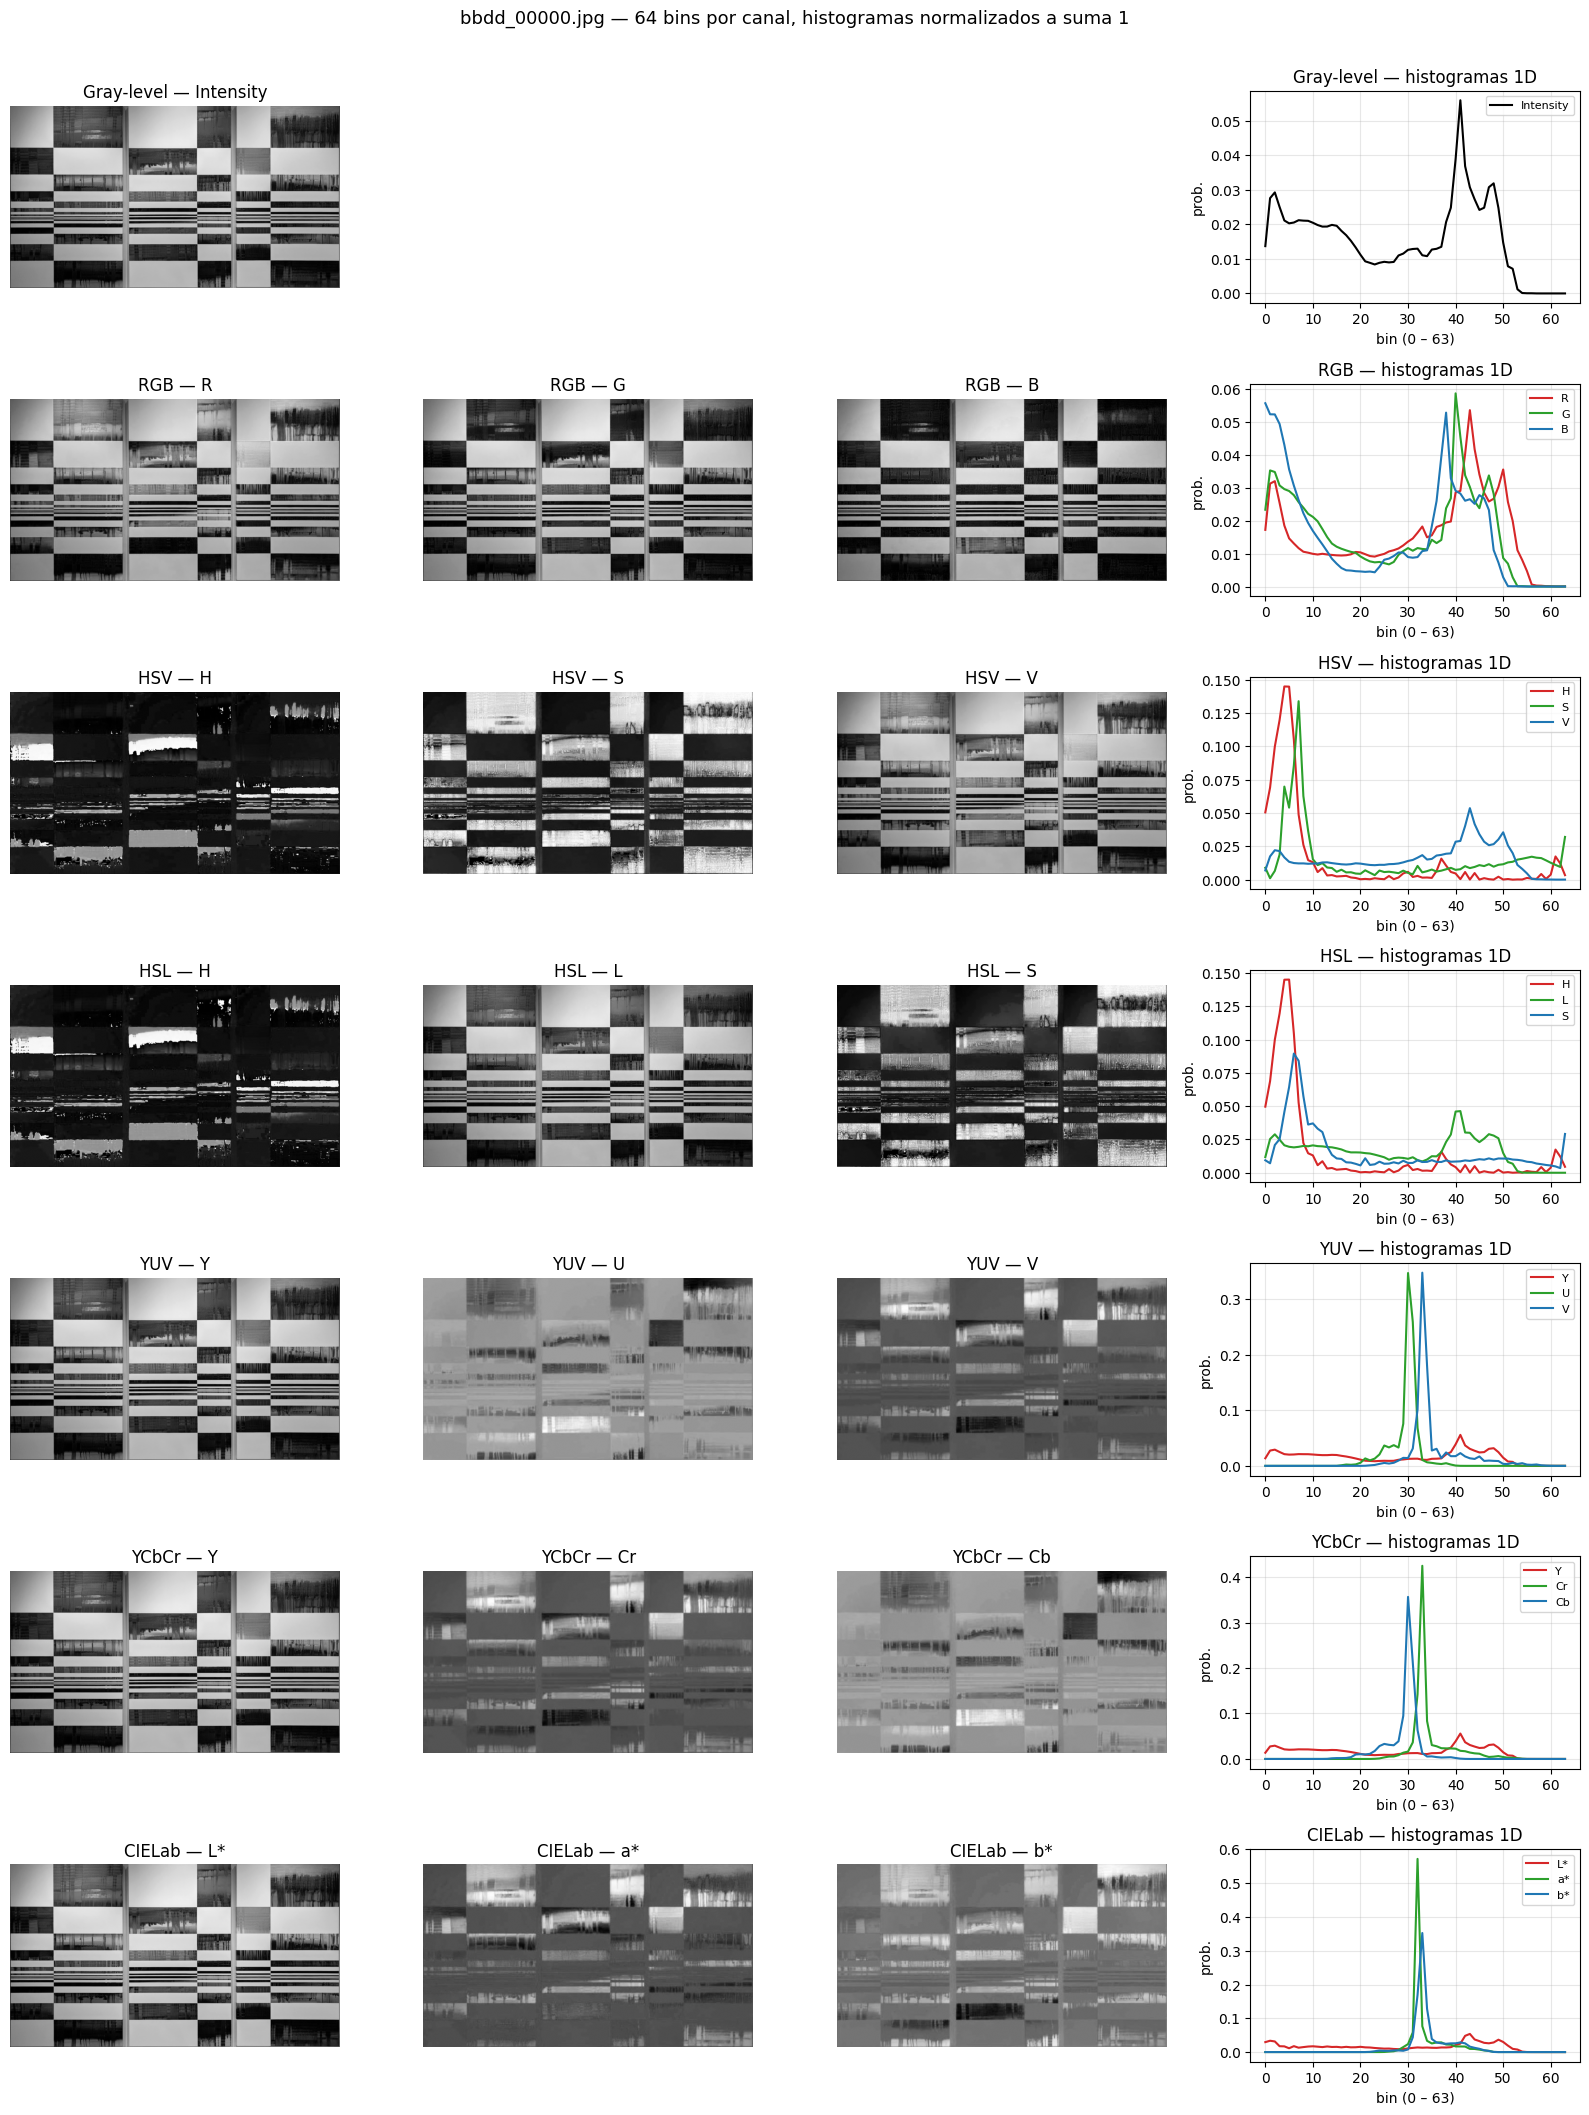

In [1]:
"""Grid: imagen + histogramas 1D en los 7 espacios de color de la teoría."""
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- Config: cambiar el path para inspeccionar otra imagen ---
IMAGE_PATH = Path("../../../Project/DATA/BBDD/bbdd_00000.jpg")
NBINS = 64

img_bgr = cv2.imread(str(IMAGE_PATH))
if img_bgr is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {IMAGE_PATH.resolve()}")

# 7 espacios de color de la teoría (S01 slide 5 + W1 slide 7).
# Cada entrada: nombre, cv2 code, nombres de canal, rango por canal (para np.histogram).
color_spaces = [
    ("Gray-level", cv2.COLOR_BGR2GRAY,  ("Intensity",),     [(0, 256)]),
    ("RGB",        cv2.COLOR_BGR2RGB,   ("R", "G", "B"),    [(0, 256)] * 3),
    ("HSV",        cv2.COLOR_BGR2HSV,   ("H", "S", "V"),    [(0, 180), (0, 256), (0, 256)]),
    ("HSL",        cv2.COLOR_BGR2HLS,   ("H", "L", "S"),    [(0, 180), (0, 256), (0, 256)]),
    ("YUV",        cv2.COLOR_BGR2YUV,   ("Y", "U", "V"),    [(0, 256)] * 3),
    ("YCbCr",      cv2.COLOR_BGR2YCrCb, ("Y", "Cr", "Cb"),  [(0, 256)] * 3),
    ("CIELab",     cv2.COLOR_BGR2Lab,   ("L*", "a*", "b*"), [(0, 256)] * 3),
]
channel_colors = ["tab:red", "tab:green", "tab:blue"]

fig, axes = plt.subplots(len(color_spaces), 4, figsize=(16, 3 * len(color_spaces)))
fig.suptitle(
    f"{IMAGE_PATH.name} — {NBINS} bins por canal, histogramas normalizados a suma 1",
    fontsize=13, y=1.005,
)

for row, (name, code, ch_names, ch_ranges) in enumerate(color_spaces):
    img_conv = cv2.cvtColor(img_bgr, code)
    channels = [img_conv] if img_conv.ndim == 2 else [img_conv[..., c] for c in range(img_conv.shape[2])]

    # Cols 0-2: cada canal como imagen en escala de grises
    for c in range(3):
        ax = axes[row, c]
        if c < len(channels):
            ax.imshow(channels[c], cmap="gray")
            ax.set_title(f"{name} — {ch_names[c]}")
        ax.axis("off")

    # Col 3: histogramas de todos los canales superpuestos
    ax_hist = axes[row, 3]
    for c, ch in enumerate(channels):
        h, _ = np.histogram(ch.ravel(), bins=NBINS, range=ch_ranges[c])
        h = h / h.sum() if h.sum() > 0 else h
        color = "black" if len(channels) == 1 else channel_colors[c]
        ax_hist.plot(h, color=color, label=ch_names[c])
    ax_hist.set_title(f"{name} — histogramas 1D")
    ax_hist.set_xlabel(f"bin (0 – {NBINS - 1})")
    ax_hist.set_ylabel("prob.")
    ax_hist.legend(loc="upper right", fontsize=8)
    ax_hist.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Grid search — todas las combinaciones de decisiones sobre QSD1 vs BBDD

Barrido exhaustivo de las 4 decisiones libres del método (espacio,
número de bins, normalización, métrica) evaluado con **mAP@1** y
**mAP@5** sobre `qsd1_w1` (30 queries, 1 match cada una) contra
`BBDD` (287 cuadros).

### Cardinalidad

| Eje | Opciones | Detalle |
|---|---|---|
| Espacio de color | **19** | 7 de la teoría (§1) + 12 extras (§1.b) |
| Métrica | **14** | 5 de la teoría (§5) + 9 extras (§5.b) |
| `nbins` | **6** | 8, 16, 32, 64, 128, 256 |
| Normalización | **2** | sin normalizar, suma 1 |
| **Total** | **3192** | filas de la tabla |

### Notas de implementación

- Las imágenes se redimensionan a máx `512 px` en el lado mayor para
  ganar velocidad; los histogramas son invariantes al orden de los
  píxeles, así que el descriptor no se ve afectado en su forma.
- Para cada espacio se calculan los **rangos globales por canal**
  (min/max sobre BBDD ∪ QSD1) → el histograma cubre siempre el rango
  real observado, incluso para espacios con valores negativos
  (YUV, Opponent, Ohta…).
- **Todas** las combinaciones se computan aunque semánticamente algunas
  no tengan sentido (p. ej. Hellinger sobre histogramas sin normalizar):
  la propia tabla muestra que esas casillas colapsan → *evidencia
  empírica* de §4.
- Coste estimado: ~4 min en CPU.


In [2]:
"""Grid search: 19 espacios × 14 métricas × 6 bins × 2 (norm/no-norm) = 3192 filas."""
import pickle
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

# --- Config ---
ROOT      = Path("../../..")
BBDD_DIR  = ROOT / "Project/DATA/BBDD"
QSD1_DIR  = ROOT / "Project/DATA/QUERY/qsd1_w1"
GT_FILE   = QSD1_DIR / "gt_corresps.pkl"
CSV_OUT   = Path("gridsearch_qsd1_w1.csv")
MAX_DIM   = 512
BINS_LIST = [8, 16, 32, 64, 128, 256]
NORM_LIST = [False, True]
EPS       = 1e-10


def load_and_resize(paths, max_dim):
    out = []
    for p in paths:
        img = cv2.imread(str(p))
        h, w = img.shape[:2]
        m = max(h, w)
        if m > max_dim:
            s = max_dim / m
            img = cv2.resize(img, (int(w * s), int(h * s)), interpolation=cv2.INTER_AREA)
        out.append(img)
    return out


bbdd_paths = sorted(BBDD_DIR.glob("bbdd_*.jpg"))
qsd_paths  = sorted(QSD1_DIR.glob("*.jpg"))
gt         = pickle.load(open(GT_FILE, "rb"))

t = time.time()
bbdd = load_and_resize(bbdd_paths, MAX_DIM)
qsd  = load_and_resize(qsd_paths, MAX_DIM)
print(f"Loaded in {time.time() - t:.1f}s:  BBDD={len(bbdd)}  QSD1={len(qsd)}  GT={len(gt)}")


# ---------- Color-space converters (BGR uint8 -> HxWxC float32) ----------
def cs_gray(img):    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)[..., None]
def cs_rgb(img):     return cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
def cs_hsv(img):     return cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
def cs_hls(img):     return cv2.cvtColor(img, cv2.COLOR_BGR2HLS).astype(np.float32)
def cs_yuv(img):     return cv2.cvtColor(img, cv2.COLOR_BGR2YUV).astype(np.float32)
def cs_ycrcb(img):   return cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb).astype(np.float32)
def cs_lab(img):     return cv2.cvtColor(img, cv2.COLOR_BGR2Lab).astype(np.float32)
def cs_xyz(img):     return cv2.cvtColor(img, cv2.COLOR_BGR2XYZ).astype(np.float32)
def cs_luv(img):     return cv2.cvtColor(img, cv2.COLOR_BGR2Luv).astype(np.float32)


def cs_hsi(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    i = rgb.mean(axis=2, keepdims=True)
    return np.concatenate([hsv[..., :1], hsv[..., 1:2], i], axis=2)


def cs_normrgb(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    return rgb / (rgb.sum(axis=2, keepdims=True) + EPS)


def cs_rg(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    return rgb[..., :2] / (rgb.sum(axis=2, keepdims=True) + EPS)


def cs_logrgb(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    return np.log(rgb + 1.0)


def _mat(rgb, M):
    return (rgb @ M.T).astype(np.float32)


def cs_yiq(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    M = np.array([[0.299, 0.587, 0.114], [0.596, -0.274, -0.322], [0.211, -0.523, 0.312]], np.float32)
    return _mat(rgb, M)


def cs_ypbpr(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    M = np.array([[0.299, 0.587, 0.114], [-0.168736, -0.331264, 0.5], [0.5, -0.418688, -0.081312]], np.float32)
    return _mat(rgb, M)


def cs_ydbdr(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    M = np.array([[0.299, 0.587, 0.114], [-0.450, -0.883, 1.333], [-1.333, 1.116, 0.217]], np.float32)
    return _mat(rgb, M)


def cs_opponent(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    return np.stack([(r - g) / np.sqrt(2), (r + g - 2 * b) / np.sqrt(6), (r + g + b) / np.sqrt(3)], axis=-1)


def cs_ohta(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    return np.stack([(r + g + b) / 3.0, r - b, (2 * g - r - b) / 2.0], axis=-1)


def cs_hmmd(img):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    h = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[..., 0].astype(np.float32)
    mx, mn = rgb.max(axis=2), rgb.min(axis=2)
    return np.stack([h, mx, mn, mx - mn], axis=-1)


SPACES = {
    # Teoría (§1)
    "Gray":     ("theory", cs_gray),
    "RGB":      ("theory", cs_rgb),
    "HSV":      ("theory", cs_hsv),
    "HSL":      ("theory", cs_hls),
    "YUV":      ("theory", cs_yuv),
    "YCbCr":    ("theory", cs_ycrcb),
    "CIELab":   ("theory", cs_lab),
    # Extras (§1.b)
    "XYZ":      ("extra", cs_xyz),
    "CIELuv":   ("extra", cs_luv),
    "HSI":      ("extra", cs_hsi),
    "NormRGB":  ("extra", cs_normrgb),
    "rg":       ("extra", cs_rg),
    "LogRGB":   ("extra", cs_logrgb),
    "YIQ":      ("extra", cs_yiq),
    "YPbPr":    ("extra", cs_ypbpr),
    "YDbDr":    ("extra", cs_ydbdr),
    "Opponent": ("extra", cs_opponent),
    "Ohta":     ("extra", cs_ohta),
    "HMMD":     ("extra", cs_hmmd),
}


# ---------- Métricas (vectorizadas: q shape (dim,), D shape (N, dim) -> (N,)) ----------
def dist_l1(q, D):        return np.abs(q - D).sum(axis=1)
def dist_l2(q, D):        return np.sqrt(((q - D) ** 2).sum(axis=1))
def dist_chi2(q, D):      return ((q - D) ** 2 / (q + D + EPS)).sum(axis=1)
def sim_intersect(q, D):  return np.minimum(q, D).sum(axis=1)
def sim_hellinger(q, D):  return np.sqrt(np.clip(q * D, 0, None)).sum(axis=1)
def dist_cheb(q, D):      return np.abs(q - D).max(axis=1)
def dist_canb(q, D):      return (np.abs(q - D) / (np.abs(q) + np.abs(D) + EPS)).sum(axis=1)
def dist_bhat(q, D):      return -np.log(np.sqrt(np.clip(q * D, 0, None)).sum(axis=1) + EPS)
def dist_kl(q, D):        return (q * (np.log(q + EPS) - np.log(D + EPS))).sum(axis=1)


def dist_js(q, D):
    m = (q + D) / 2.0
    kl_qm = (q * (np.log(q + EPS) - np.log(m + EPS))).sum(axis=1)
    kl_dm = (D * (np.log(D + EPS) - np.log(m + EPS))).sum(axis=1)
    return 0.5 * (kl_qm + kl_dm)


def sim_cos(q, D):
    return (q * D).sum(axis=1) / (np.linalg.norm(q) * np.linalg.norm(D, axis=1) + EPS)


def sim_pearson(q, D):
    qc = q - q.mean()
    Dc = D - D.mean(axis=1, keepdims=True)
    return (qc * Dc).sum(axis=1) / (np.linalg.norm(qc) * np.linalg.norm(Dc, axis=1) + EPS)


def dist_emd(q, D):
    return np.abs(np.cumsum(q) - np.cumsum(D, axis=1)).sum(axis=1)


def dist_ks(q, D):
    return np.abs(np.cumsum(q) - np.cumsum(D, axis=1)).max(axis=1)


METRICS = {
    # Teoría (§5)
    "L1":            ("theory", "distance",   dist_l1),
    "L2":            ("theory", "distance",   dist_l2),
    "chi2":          ("theory", "distance",   dist_chi2),
    "intersection":  ("theory", "similarity", sim_intersect),
    "hellinger":     ("theory", "similarity", sim_hellinger),
    # Extras (§5.b)
    "chebyshev":     ("extra",  "distance",   dist_cheb),
    "canberra":      ("extra",  "distance",   dist_canb),
    "bhattacharyya": ("extra",  "distance",   dist_bhat),
    "kl":            ("extra",  "distance",   dist_kl),
    "js":            ("extra",  "distance",   dist_js),
    "cosine":        ("extra",  "similarity", sim_cos),
    "pearson":       ("extra",  "similarity", sim_pearson),
    "emd":           ("extra",  "distance",   dist_emd),
    "ks":            ("extra",  "distance",   dist_ks),
}


# ---------- Helpers ----------
def global_ranges(imgs):
    n_ch = imgs[0].shape[-1]
    out = []
    for c in range(n_ch):
        vals = np.concatenate([x[..., c].ravel() for x in imgs])
        lo, hi = float(vals.min()), float(vals.max())
        if hi <= lo:
            hi = lo + 1.0
        out.append((lo, hi + 1e-6))
    return out


def descriptors(imgs_conv, nbins, ranges):
    n_ch = imgs_conv[0].shape[-1]
    D = np.zeros((len(imgs_conv), n_ch * nbins), dtype=np.float64)
    for i, x in enumerate(imgs_conv):
        parts = [np.histogram(x[..., c].ravel(), bins=nbins, range=ranges[c])[0] for c in range(n_ch)]
        D[i] = np.concatenate(parts)
    return D


def ap_at_k(order, relevant, k):
    hits, s = 0, 0.0
    for i, idx in enumerate(order[:k], start=1):
        if idx in relevant:
            hits += 1
            s += hits / i
    return s / (min(len(relevant), k) if relevant else 1)


def map_at_k(orders, gt, k):
    return float(np.mean([
        ap_at_k(o, set(g) if isinstance(g, (list, tuple)) else {g}, k)
        for o, g in zip(orders, gt)
    ]))


# ---------- Grid loop ----------
rows = []
total = len(SPACES) * len(BINS_LIST) * len(NORM_LIST) * len(METRICS)
print(f"Running grid search: {total} combinations")
t0 = time.time()

for si, (sname, (skind, conv)) in enumerate(SPACES.items(), start=1):
    ts = time.time()
    conv_b = [conv(x) for x in bbdd]
    conv_q = [conv(x) for x in qsd]
    n_ch = conv_b[0].shape[-1]
    rngs = global_ranges(conv_b + conv_q)

    for nbins in BINS_LIST:
        Dbase_b = descriptors(conv_b, nbins, rngs)
        Dbase_q = descriptors(conv_q, nbins, rngs)
        for norm_flag in NORM_LIST:
            if norm_flag:
                Db = Dbase_b / (Dbase_b.sum(axis=1, keepdims=True) + EPS)
                Dq = Dbase_q / (Dbase_q.sum(axis=1, keepdims=True) + EPS)
            else:
                Db = Dbase_b.astype(np.float64)
                Dq = Dbase_q.astype(np.float64)
            for mname, (mkind, direction, fn) in METRICS.items():
                orders = []
                for q in Dq:
                    sc = fn(q, Db)
                    if np.any(np.isnan(sc)):
                        sc = np.nan_to_num(sc, nan=(-np.inf if direction == "similarity" else np.inf))
                    order = np.argsort(sc) if direction == "distance" else np.argsort(-sc)
                    orders.append(order[:5].tolist())
                rows.append({
                    "space": sname, "space_from": skind, "channels": n_ch,
                    "nbins": nbins, "dim": n_ch * nbins, "norm_sum1": norm_flag,
                    "metric": mname, "metric_from": mkind, "direction": direction,
                    "mAP@1": map_at_k(orders, gt, 1),
                    "mAP@5": map_at_k(orders, gt, 5),
                })
    print(f"  [{si:2d}/{len(SPACES)}] {sname:9s}  {n_ch} ch  {time.time() - ts:5.1f}s")
    del conv_b, conv_q

results_df = pd.DataFrame(rows)
results_df.to_csv(CSV_OUT, index=False)
print(f"\nDone in {time.time() - t0:.1f}s.  Rows: {len(results_df)}")
print(f"CSV: {CSV_OUT.resolve()}")

Loaded in 5.1s:  BBDD=287  QSD1=30  GT=30
Running grid search: 3192 combinations
  [ 1/19] Gray       1 ch    3.8s
  [ 2/19] RGB        3 ch   13.6s
  [ 3/19] HSV        3 ch   13.4s
  [ 4/19] HSL        3 ch   12.9s
  [ 5/19] YUV        3 ch    9.9s
  [ 6/19] YCbCr      3 ch   11.1s
  [ 7/19] CIELab     3 ch   10.6s
  [ 8/19] XYZ        3 ch    8.9s
  [ 9/19] CIELuv     3 ch   10.1s
  [10/19] HSI        3 ch   10.7s
  [11/19] NormRGB    3 ch   10.5s
  [12/19] rg         2 ch    7.4s
  [13/19] LogRGB     3 ch    9.5s
  [14/19] YIQ        3 ch   12.1s
  [15/19] YPbPr      3 ch   14.7s
  [16/19] YDbDr      3 ch   13.0s
  [17/19] Opponent   3 ch   20.6s
  [18/19] Ohta       3 ch   14.2s
  [19/19] HMMD       4 ch   23.9s

Done in 230.9s.  Rows: 3192
CSV: /home/martinmarch/MSC computer vision/Introduction to Human and Computer Vision/Code/Team4/analysis/gridsearch_qsd1_w1.csv


In [5]:
"""Tablas resumen del grid search."""
from IPython.display import display

# Si el grid ya se ejecutó, `results_df` está en memoria; si no, cargar el CSV.
try:
    results_df  # noqa: F821
except NameError:
    results_df = pd.read_csv("gridsearch_qsd1_w1.csv")

cols = ["space", "space_from", "channels", "nbins", "dim",
        "norm_sum1", "metric", "metric_from", "mAP@1", "mAP@5"]


print("=" * 70)
print("TOP 20 combinaciones globales (por mAP@5)")
print("=" * 70)
top20 = results_df.sort_values(["mAP@5", "mAP@1"], ascending=False).head(20)
display(top20[cols].reset_index(drop=True).style.format({"mAP@1": "{:.3f}", "mAP@5": "{:.3f}"}))


print("\n" + "=" * 70)
print("TOP 10 restringido a TEORÍA (espacios §1 + métricas §5) — la 'entrega canon'")
print("=" * 70)
theory_only = results_df[
    (results_df["space_from"] == "theory") & (results_df["metric_from"] == "theory")
].sort_values(["mAP@5", "mAP@1"], ascending=False).head(10)
display(theory_only[cols].reset_index(drop=True).style.format({"mAP@1": "{:.3f}", "mAP@5": "{:.3f}"}))


print("\n" + "=" * 70)
print("Mejor combo POR ESPACIO (todas las métricas permitidas)")
print("=" * 70)
best_by_space = (
    results_df.sort_values("mAP@5", ascending=False)
              .groupby("space", as_index=False).head(1)
              .sort_values("mAP@5", ascending=False)
)
display(best_by_space[cols].reset_index(drop=True).style.format({"mAP@1": "{:.3f}", "mAP@5": "{:.3f}"}))


print("\n" + "=" * 70)
print("Mejor combo POR MÉTRICA (todos los espacios permitidos)")
print("=" * 70)
best_by_metric = (
    results_df.sort_values("mAP@5", ascending=False)
              .groupby("metric", as_index=False).head(1)
              .sort_values("mAP@5", ascending=False)
)
display(best_by_metric[cols].reset_index(drop=True).style.format({"mAP@1": "{:.3f}", "mAP@5": "{:.3f}"}))


print("\n" + "=" * 70)
print("Efecto de la normalización — media de mAP@5 por (norm_sum1)")
print("=" * 70)
display(
    results_df.groupby("norm_sum1")["mAP@5"].agg(["mean", "median", "max"]).round(3)
)

TOP 20 combinaciones globales (por mAP@5)


,space,space_from,channels,nbins,dim,norm_sum1,metric,metric_from,mAP@1,mAP@5
0,HMMD,extra,4,16,64,True,canberra,extra,0.600,0.683
1,HSV,theory,3,16,48,True,canberra,extra,0.667,0.675
2,HMMD,extra,4,32,128,True,canberra,extra,0.600,0.662
3,HSV,theory,3,8,24,True,canberra,extra,0.567,0.656
4,CIELab,theory,3,32,96,True,canberra,extra,0.567,0.648
5,CIELab,theory,3,16,48,True,canberra,extra,0.600,0.644
6,HMMD,extra,4,8,32,True,canberra,extra,0.567,0.644
7,CIELuv,extra,3,32,96,True,canberra,extra,0.600,0.642
8,CIELab,theory,3,32,96,True,L1,theory,0.533,0.639
9,CIELab,theory,3,32,96,True,intersection,theory,0.533,0.639



TOP 10 restringido a TEORÍA (espacios §1 + métricas §5) — la 'entrega canon'


,space,space_from,channels,nbins,dim,norm_sum1,metric,metric_from,mAP@1,mAP@5
0,CIELab,theory,3,32,96,True,L1,theory,0.533,0.639
1,CIELab,theory,3,32,96,True,intersection,theory,0.533,0.639
2,HSV,theory,3,16,48,True,chi2,theory,0.533,0.601
3,CIELab,theory,3,32,96,True,chi2,theory,0.500,0.598
4,HSV,theory,3,16,48,True,hellinger,theory,0.533,0.597
5,CIELab,theory,3,16,48,True,L1,theory,0.500,0.587
6,CIELab,theory,3,16,48,True,intersection,theory,0.500,0.587
7,HSV,theory,3,16,48,True,L1,theory,0.500,0.586
8,HSV,theory,3,16,48,True,intersection,theory,0.500,0.586
9,CIELab,theory,3,128,384,True,L1,theory,0.500,0.579



Mejor combo POR ESPACIO (todas las métricas permitidas)


,space,space_from,channels,nbins,dim,norm_sum1,metric,metric_from,mAP@1,mAP@5
0,HMMD,extra,4,16,64,True,canberra,extra,0.600,0.683
1,HSV,theory,3,16,48,True,canberra,extra,0.667,0.675
2,CIELab,theory,3,32,96,True,canberra,extra,0.567,0.648
3,CIELuv,extra,3,32,96,True,canberra,extra,0.600,0.642
4,rg,extra,2,32,64,True,chi2,theory,0.567,0.634
5,HSI,extra,3,16,48,True,canberra,extra,0.500,0.618
6,YIQ,extra,3,32,96,True,canberra,extra,0.567,0.608
7,YPbPr,extra,3,16,48,True,canberra,extra,0.533,0.601
8,YDbDr,extra,3,16,48,True,canberra,extra,0.533,0.593
9,YCbCr,theory,3,32,96,True,canberra,extra,0.533,0.590



Mejor combo POR MÉTRICA (todos los espacios permitidos)


,space,space_from,channels,nbins,dim,norm_sum1,metric,metric_from,mAP@1,mAP@5
0,HMMD,extra,4,16,64,True,canberra,extra,0.600,0.683
1,CIELab,theory,3,32,96,True,intersection,theory,0.533,0.639
2,CIELab,theory,3,32,96,True,L1,theory,0.533,0.639
3,rg,extra,2,32,64,True,chi2,theory,0.567,0.634
4,rg,extra,2,32,64,True,hellinger,theory,0.533,0.621
5,rg,extra,2,32,64,True,bhattacharyya,extra,0.533,0.621
6,HSV,theory,3,16,48,True,kl,extra,0.567,0.619
7,rg,extra,2,32,64,True,js,extra,0.533,0.614
8,HSL,theory,3,16,48,True,emd,extra,0.467,0.544
9,CIELuv,extra,3,32,96,True,L2,theory,0.500,0.513



Efecto de la normalización — media de mAP@5 por (norm_sum1)


,mean,median,max
norm_sum1,,,
False,0.295,0.291,0.612
True,0.408,0.414,0.683
